In [ ]:
# 1. 导入依赖库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
def detect_data_structure(df):
    """探测数据结构：识别样本编码列、标签列及数据类型"""
    print("=== 数据结构探测结果 ===")
    # 2.1 输出前5列与后5列名称，确认第一列（样本编码）和最后一列（标签）
    print(f"前5列名称：{df.columns[:5].tolist()}")
    print(f"后5列名称：{df.columns[-5:].tolist()}")
    print(f"第一列（样本编码）名称：{df.columns[0]}")
    print(f"最后一列（标签）名称：{df.columns[-1]}")

    # 2.2 检测各列数据类型
    dtype_counts = df.dtypes.value_counts()
    print(f"\n数据类型分布：\n{dtype_counts}")

    # 2.3 检测标签列类型（可能为字符串或数值）
    label_col = df.columns[-1]
    print(f"\n标签列（{label_col}）唯一值：{df[label_col].unique()}")
    print(f"标签列（{label_col}）值计数：\n{df[label_col].value_counts()}")

    # 2.4 检测样本编码列（第一列）是否为字符串（通常样本ID为字符串）
    id_col = df.columns[0]
    print(f"\n样本编码列（{id_col}）前5个值：{df[id_col].head().tolist()}")
    print(f"样本编码列（{id_col}）数据类型：{df[id_col].dtype}")

    return id_col, label_col

In [ ]:
a = pd.read_csv('LUSCexpfile.csv',sep = ';')
y_col = a.iloc[0,1:].values
df = a.iloc[1:,:].set_index(a.columns[0]).T
df['y'] = y_col

In [ ]:
id_col, label_col = detect_data_structure(df)# 探测数据结构

In [34]:
#列名查重
col_counts = df.columns.value_counts()
dup_cols = col_counts[col_counts > 1].index.tolist()
print(dup_cols)

['RF00019', 'RF00017', 'RF00012', 'RF02271', 'RF01210', 'RF00156', 'RF00322', 'RF00096', 'RF00561', 'RF00402', 'RF00004', 'RF00003', 'RF00432', 'RF00554', 'RF00568', 'RF01518', 'RF00026', 'RF00092', 'RF00272', 'RF00100', 'RF00139', 'RF00066', 'RF00425', 'RF00072', 'RF00181', 'RF01225', 'RF01233', 'RF00284', 'RF00275', 'RF00614', 'RF00015', 'RF00601', 'RF00091', 'RF00560', 'RF00416', 'RF00409', 'RF00424', 'RF00279', 'RF00090', 'RF00006', 'RF00393', 'RF00334', 'RF00443', 'RF00492', 'RF00394', 'RF00045', 'RF00494', 'RF00157', 'RF00285', 'RF00263', 'RF00264', 'RF00591', 'RF00410', 'RF00413', 'RF00001', 'RF00108', 'RF00421', 'RF00136', 'RF01241', 'RF00212', 'RF00408', 'DSE', 'RF00426', 'RF00564', 'RF00191', 'RF02110', 'RF00411', 'RF00401', 'RF00056', 'RF00438', 'RF00271', 'RF00422', 'HCG23', 'RF00190', 'RF02219', 'RF02171', 'ALG1L9P', 'RF00273', 'LOC644634', 'SNORD3D', 'RF00283', 'RF00278', 'COG8', 'RF00093', 'RF02116', 'ARL14EPL', 'MIA2', 'RF00324', 'RF00154', 'RMRP', 'PRAMEF7', 'RF00150',

In [56]:
#重命名重复列
import random
new_columns = []
col_name_counter = {}
for col in df.columns:
    if col not in col_name_counter:
        col_name_counter[col] = 1
        new_columns.append(col)
    else:
        col_name_counter[col]+=1
        new_columns.append(f"{col}_{col_name_counter[col]}")
df.columns = new_columns
df.head()

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,y
03611591-08da-45c5-bfe5-ce511a2cc341,0.108403483,1.187325638,0.001370356,459.7836081,0.486278098,0.027029014,0,0,0.084772552,0.064318308,...,0.860664,2.226001,5.013749,0.00841,0.0,4.194418,99.369159,0.0,4.552543,normal
045e2535-012c-4cec-b386-9d6f62b91829,0.095187869,0.594016407,0.032045614,648.0057316,1.080389631,0.055878692,0.029601196,0,0.04022254,0.143868178,...,1.232901,3.272293,5.482293,0.025654,0.0,4.662835,98.084795,0.0,5.626856,normal
118933b6-86c7-4668-9973-424ece352a60,0.097042537,1.012277195,0,444.8724975,1.047980517,0.012098154,0,0,0.178337234,0.017273278,...,0.72607,1.60696,2.783768,0.037645,0.0,4.619178,54.605189,0.0,2.309259,normal
153cb1b1-774c-4e65-b209-6a462b68cfc5,0.04302861,1.015939279,0,751.7312734,0.780322401,0.021787373,0.029335026,0.03435086,0.082568933,0.025922643,...,0.844632,2.43637,4.161483,0.042371,0.0,4.814995,86.273891,0.0,5.302771,normal
18f0b34c-d2f6-4746-b450-8ed3def9e334,0.095016254,1.174120262,0,1385.150034,0.721304607,0.048111117,0,0,0.182329632,0.057242667,...,0.854256,2.22553,4.401694,0.006238,0.0,5.432338,93.666207,0.0,5.399341,normal


In [57]:
df.coliumns

AttributeError: 'DataFrame' object has no attribute 'coliumns'

In [58]:
# 3. 数据预处理（适配未知数据类型与特殊列）
# 3.1 分离样本编码列（仅保留，不作为特征）、特征列、标签列
id_series = df[id_col]  # 保存样本编码，用于后续溯源（如错误样本分析）
# 特征列：排除第一列（样本编码）和最后一列（标签）
X = df.drop(columns=[id_col, label_col])
# 标签列：处理可能的字符串类型（如"normal"/"cancer"）
y = df[label_col]
# 3.2 标签列数据类型转换（字符串→数值）
y_encoded = y.map({'normal':0,"tumor":1})
y = y_encoded

In [76]:
# 3.3 特征列数据类型转换（确保为数值类型）
print(f"\n特征列数据类型处理前：")
count = 0
non_numeric_cols = X.select_dtypes(exclude=["int64", "float64"]).columns
if len(non_numeric_cols) > 0:
    print(f"发现非数值特征列个数：{len(non_numeric_cols.tolist())}，进行转换...")
    # 尝试转换为数值类型，无法转换的列删除（通常为异常列）
    for col in non_numeric_cols:
        if count % 100 == 0:
            print("已转换完成：{:.2f}%".format(100*count/len(non_numeric_cols)))
        X[col] = pd.to_numeric(X[col], errors="coerce")  # 无法转换的值设为NaN
        count += 1
    print('*'*10+"转换完成"+'*'*10)
    # 删除全为NaN的非数值列
    X = X.dropna(axis=1, how="all")
    print(f"处理后特征列数：{X.shape[1]}（删除全为NaN的非数值列）")
else:
    print("所有特征列均为数值类型，无需转换")


特征列数据类型处理前：
发现非数值特征列个数：56906，进行转换...
已转换完成：30.75%
已转换完成：30.93%
已转换完成：31.10%
已转换完成：31.28%
已转换完成：31.46%
已转换完成：31.63%
已转换完成：31.81%
已转换完成：31.98%
已转换完成：32.16%
已转换完成：32.33%
已转换完成：32.51%
已转换完成：32.69%
已转换完成：32.86%
已转换完成：33.04%
已转换完成：33.21%
已转换完成：33.39%
已转换完成：33.56%
已转换完成：33.74%
已转换完成：33.92%
已转换完成：34.09%
已转换完成：34.27%
已转换完成：34.44%
已转换完成：34.62%
已转换完成：34.79%
已转换完成：34.97%
已转换完成：35.15%
已转换完成：35.32%
已转换完成：35.50%
已转换完成：35.67%
已转换完成：35.85%
已转换完成：36.02%
已转换完成：36.20%
已转换完成：36.38%
已转换完成：36.55%
已转换完成：36.73%
已转换完成：36.90%
已转换完成：37.08%
已转换完成：37.25%
已转换完成：37.43%
已转换完成：37.61%
已转换完成：37.78%
已转换完成：37.96%
已转换完成：38.13%
已转换完成：38.31%
已转换完成：38.48%
已转换完成：38.66%
已转换完成：38.84%
已转换完成：39.01%
已转换完成：39.19%
已转换完成：39.36%
已转换完成：39.54%
已转换完成：39.71%
已转换完成：39.89%
已转换完成：40.07%
已转换完成：40.24%
已转换完成：40.42%
已转换完成：40.59%
已转换完成：40.77%
已转换完成：40.94%
已转换完成：41.12%
已转换完成：41.30%
已转换完成：41.47%
已转换完成：41.65%
已转换完成：41.82%
已转换完成：42.00%
已转换完成：42.17%
已转换完成：42.35%
已转换完成：42.53%
已转换完成：42.70%
已转换完成：42.88%
已转换完成：43.05%
已转换完成：43.23%
已转换完成：43.40%
已转换完成：43.58%


In [79]:
# 3.4 缺失值处理（基因表达用中位数填充，避免均值受极端值影响）
print(f"\n缺失值统计：")
missing_stats = X.isnull().sum()
missing_cols = missing_stats[missing_stats > 0]
if len(missing_cols) > 0:
    print(f"存在缺失值的特征列数：{len(missing_cols)}")
    print(f"缺失值最多的前5列：\n{missing_cols.sort_values(ascending=False).head()}")
    # 中位数填充（基因表达数据适合用中位数）
    X = X.fillna(X.median())
    print("缺失值已用中位数填充")
else:
    print("无缺失值")


缺失值统计：
无缺失值


In [80]:
# 3.5 样本不平衡处理（已知49正常/502癌症，比例~1:10）
print(f"\n处理前样本分布：")
print(f"正常样本数（0）：{len(y[y == 0])}")
print(f"癌症样本数（1）：{len(y[y == 1])}")
print(f"样本不平衡比例：{max(len(y[y == 0]), len(y[y == 1])) / min(len(y[y == 0]), len(y[y == 1])):.1f}:1")



处理前样本分布：
正常样本数（0）：49
癌症样本数（1）：502
样本不平衡比例：10.2:1


In [81]:
# 使用SMOTE过采样（k_neighbors设为5，确保正常样本数足够）
if len(y[y == 0]) >= 5:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_balanced, y_balanced = smote.fit_resample(X, y)
    print(f"\nSMOTE平衡后样本分布：")
    print(f"正常样本数（0）：{len(y_balanced[y_balanced == 0])}")
    print(f"癌症样本数（1）：{len(y_balanced[y_balanced == 1])}")
else:
    print("\n正常样本数不足5，无法使用SMOTE，直接使用原始数据")
    X_balanced, y_balanced = X, y


SMOTE平衡后样本分布：
正常样本数（0）：502
癌症样本数（1）：502


In [82]:
# 3.6 数据拆分（7:3分层拆分，保证标签分布一致）
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
)
# 保存测试集样本编码（用于后续错误分析）
test_id = id_series.iloc[X_test.index] if len(X_balanced) == len(df) else None
print(f"\n数据拆分结果：")
print(f"训练集：{X_train.shape[0]}个样本 × {X_train.shape[1]}个特征")
print(f"测试集：{X_test.shape[0]}个样本 × {X_test.shape[1]}个特征")


数据拆分结果：
训练集：702个样本 × 56906个特征
测试集：302个样本 × 56906个特征


In [83]:
# 3.7 特征标准化（TPM已标准化，但需消除基因间量纲差异）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n特征标准化完成（Z-score标准化）")


特征标准化完成（Z-score标准化）


In [84]:
# 4. 特征工程（高维降维：适配56907个基因特征）
# 4.1 差异基因筛选（SelectKBest选Top300，平衡特征数与区分度）
print(f"\n特征筛选：使用ANOVA F检验筛选Top300核心基因...")
selector = SelectKBest(score_func=f_classif, k=min(300, X_train_scaled.shape[1]))  # 避免k超过特征数
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# 提取筛选后的核心基因名
selected_gene_mask = selector.get_support()
selected_gene_names = X.columns[selected_gene_mask]
print(f"筛选后核心基因数：{len(selected_gene_names)}")
print(f"Top10核心基因（按F-score排序）：{selected_gene_names[:10].tolist()}")


特征筛选：使用ANOVA F检验筛选Top300核心基因...
筛选后核心基因数：300
Top10核心基因（按F-score排序）：['A2M', 'ABCA8', 'ABCC6', 'ABI3BP', 'AC005856.1', 'AC005884.1', 'AC021016.2', 'AC037459.2', 'AC079630.1', 'AC090559.1']


In [85]:
# 4.2 PCA降维（进一步降维至20维，减少计算量并避免过拟合）
print(f"\nPCA降维：将{X_train_selected.shape[1]}个核心基因降维至20维...")
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)
print(f"PCA降维结果：训练集{X_train_pca.shape}，测试集{X_test_pca.shape}")
print(f"PCA累计解释方差比：{pca.explained_variance_ratio_.sum():.4f}（保留>70%方差为宜）")



PCA降维：将300个核心基因降维至20维...
PCA降维结果：训练集(702, 20)，测试集(302, 20)
PCA累计解释方差比：0.9540（保留>70%方差为宜）


In [86]:
# 5. 模型训练与超参数调优（随机森林+SVM对比）
def train_and_optimize_model(model, param_grid, X_train, y_train, model_name):
    """训练模型并进行网格搜索调优"""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        model, param_grid, cv=skf, scoring="roc_auc", n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)
    print(f"\n{model_name}最优参数：{grid_search.best_params_}")
    print(f"{model_name}5折交叉验证AUC：{grid_search.best_score_:.4f}")
    return grid_search.best_estimator_

In [87]:
# 5.1 随机森林模型（抗过拟合，适合高维数据，可输出特征重要性）
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_best = train_and_optimize_model(rf_model, rf_param_grid, X_train_pca, y_train, "随机森林")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

随机森林最优参数：{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
随机森林5折交叉验证AUC：0.9989


In [88]:
# 5.2 SVM模型（小样本高维数据表现优，适合基因表达数据）
svm_param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"]
}
svm_model = SVC(probability=True, random_state=42)
svm_best = train_and_optimize_model(svm_model, svm_param_grid, X_train_pca, y_train, "SVM")


Fitting 5 folds for each of 6 candidates, totalling 30 fits

SVM最优参数：{'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
SVM5折交叉验证AUC：1.0000


In [89]:
# 6. 模型评估（测试集验证，输出多维度指标）
def evaluate_model(model, X_test, y_test, model_name, test_id=None):
    """评估模型性能，返回指标、预测结果及错误样本编码"""
    # 预测结果
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # 癌症样本的预测概率

    # 计算评估指标
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_pred_prob)
    }

    # 输出评估结果
    print(f"\n=== {model_name}测试集性能 ===")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    # 识别错误预测样本（若有样本编码）
    if test_id is not None:
        error_mask = y_pred != y_test
        error_ids = test_id[error_mask]
        error_labels = pd.DataFrame({
            "样本编码": error_ids,
            "真实标签": y_test[error_mask],
            "预测标签": y_pred[error_mask],
            "预测癌症概率": y_pred_prob[error_mask]
        })
        print(f"\n{model_name}错误预测样本数：{len(error_labels)}")
        print(f"错误预测样本详情（前5个）：\n{error_labels.head()}")
        return metrics, y_pred, y_pred_prob, error_labels
    return metrics, y_pred, y_pred_prob, None


# 评估两个模型
rf_metrics, rf_y_pred, rf_y_pred_prob, rf_errors = evaluate_model(
    rf_best, X_test_pca, y_test, "随机森林", test_id
)
svm_metrics, svm_y_pred, svm_y_pred_prob, svm_errors = evaluate_model(
    svm_best, X_test_pca, y_test, "SVM", test_id
)



=== 随机森林测试集性能 ===
accuracy: 0.9967
precision: 1.0000
recall: 0.9934
f1: 0.9967
auc: 1.0000

=== SVM测试集性能 ===
accuracy: 0.9636
precision: 1.0000
recall: 0.9272
f1: 0.9622
auc: 1.0000


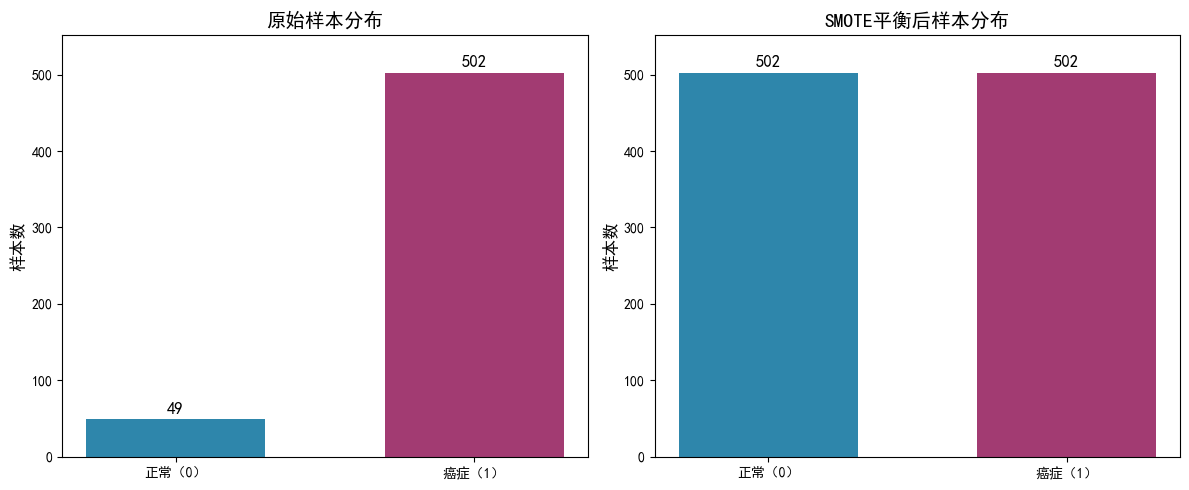

In [92]:
# 7. 结果可视化（8个核心图表，含数据结构相关可视化）
# 7.1 数据类型分布可视化 略
# 设置字体：解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows默认黑体；macOS替换为['PingFang SC']；Linux替换为['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题
# 7.2 样本分布可视化（原始vs平衡后）
plt.figure(figsize=(12, 5))
# 原始样本分布
plt.subplot(1, 2, 1)
original_counts = pd.Series(y).value_counts().sort_index()
bars1 = plt.bar(["正常（0）", "癌症（1）"], original_counts.values,
                color=["#2E86AB", "#A23B72"], width=0.6)
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 5,
             f"{int(height)}", ha="center", va="bottom", fontsize=12)
plt.title("原始样本分布", fontsize=14)
plt.ylabel("样本数", fontsize=12)
plt.ylim(0, max(original_counts.values) * 1.1)

# 平衡后样本分布
plt.subplot(1, 2, 2)
balanced_counts = pd.Series(y_balanced).value_counts().sort_index()
bars2 = plt.bar(["正常（0）", "癌症（1）"], balanced_counts.values,
                color=["#2E86AB", "#A23B72"], width=0.6)
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 5,
             f"{int(height)}", ha="center", va="bottom", fontsize=12)
plt.title("SMOTE平衡后样本分布", fontsize=14)
plt.ylabel("样本数", fontsize=12)
plt.ylim(0, max(balanced_counts.values) * 1.1)

plt.tight_layout()
plt.savefig("2_样本分布对比.png", dpi=300, bbox_inches='tight')
plt.show()

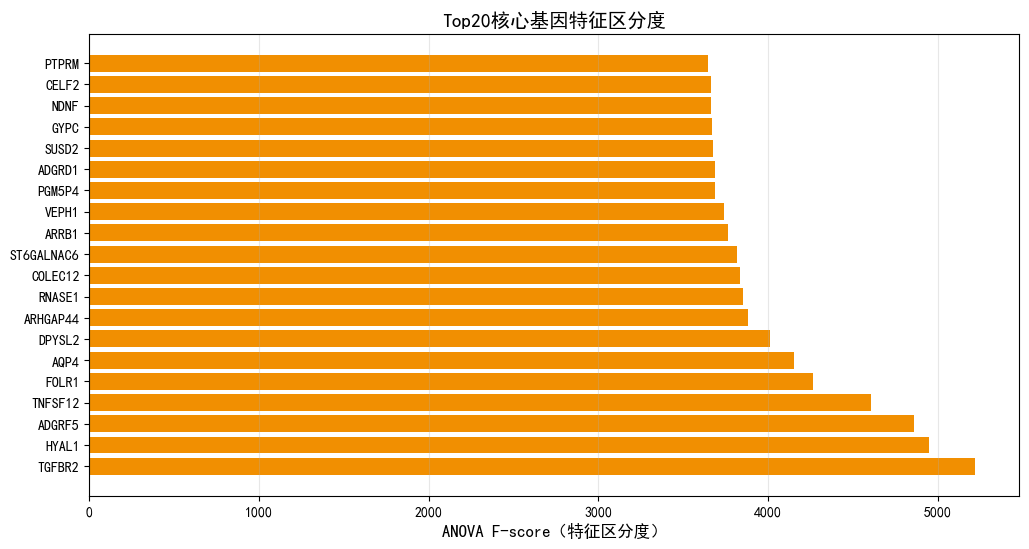

In [93]:
# 7.3 特征筛选F-score可视化（Top20核心基因）
plt.figure(figsize=(12, 6))
# 提取Top20基因的F-score
top20_gene_idx = np.argsort(selector.scores_[selected_gene_mask])[-20:]
top20_gene_names = selected_gene_names[top20_gene_idx]
top20_gene_scores = selector.scores_[selected_gene_mask][top20_gene_idx]

# 绘制水平条形图（倒序，最高分在顶部）
y_pos = np.arange(len(top20_gene_names))
plt.barh(y_pos, top20_gene_scores, color="#F18F01")
plt.yticks(y_pos, top20_gene_names, fontsize=10)
plt.xlabel("ANOVA F-score（特征区分度）", fontsize=12)
plt.title("Top20核心基因特征区分度", fontsize=14)
plt.gca().invert_yaxis()  # 倒序显示
plt.grid(axis="x", alpha=0.3)
plt.savefig("3_核心基因F-score.png", dpi=300, bbox_inches='tight')
plt.show()

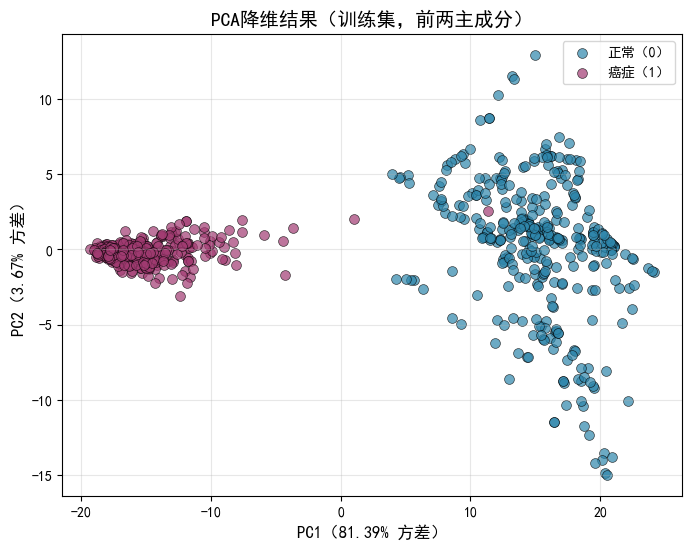

In [94]:
# 7.4 PCA降维可视化（训练集，前两主成分）
plt.figure(figsize=(8, 6))
# 正常样本
mask_normal = y_train == 0
plt.scatter(X_train_pca[mask_normal, 0], X_train_pca[mask_normal, 1],
            c="#2E86AB", label="正常（0）", alpha=0.7, s=50, edgecolors="black", linewidth=0.5)
# 癌症样本
mask_cancer = y_train == 1
plt.scatter(X_train_pca[mask_cancer, 0], X_train_pca[mask_cancer, 1],
            c="#A23B72", label="癌症（1）", alpha=0.7, s=50, edgecolors="black", linewidth=0.5)

plt.xlabel(f"PC1（{pca.explained_variance_ratio_[0]:.2%} 方差）", fontsize=12)
plt.ylabel(f"PC2（{pca.explained_variance_ratio_[1]:.2%} 方差）", fontsize=12)
plt.title("PCA降维结果（训练集，前两主成分）", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("4_PCA降维可视化.png", dpi=300, bbox_inches='tight')
plt.show()

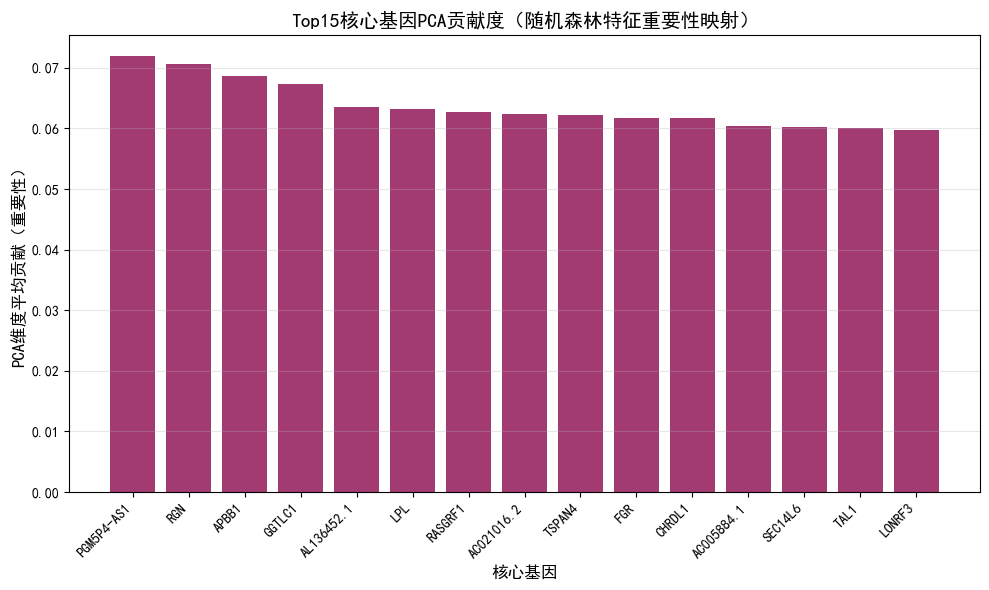

In [95]:
# 7.5 随机森林特征重要性可视化（PCA维度对应的原始基因）
plt.figure(figsize=(10, 6))
# 计算PCA维度对原始基因的贡献（通过PCA.components_）
pca_component_importance = np.abs(pca.components_).mean(axis=0)  # 各基因在所有PCA维度的平均贡献
# 映射到原始基因名并排序
gene_pca_importance = pd.Series(pca_component_importance, index=selected_gene_names)
top15_gene_importance = gene_pca_importance.sort_values(ascending=False).head(15)

# 绘制条形图
bars = plt.bar(range(len(top15_gene_importance)), top15_gene_importance.values, color="#A23B72")
plt.xticks(range(len(top15_gene_importance)), top15_gene_importance.index, rotation=45, ha="right")
plt.xlabel("核心基因", fontsize=12)
plt.ylabel("PCA维度平均贡献（重要性）", fontsize=12)
plt.title("Top15核心基因PCA贡献度（随机森林特征重要性映射）", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("5_基因PCA贡献度.png", dpi=300, bbox_inches='tight')
plt.show()

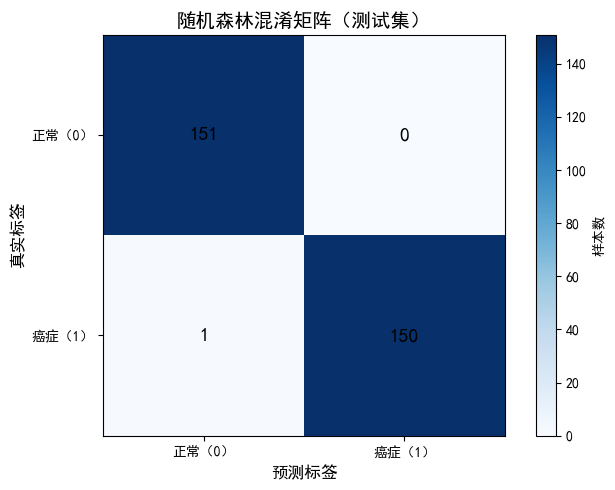

In [96]:

# 7.6 混淆矩阵可视化（随机森林，测试集）
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, rf_y_pred)
# 绘制热力图
im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im, label="样本数")
# 添加数值标注
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")
# 设置标签
plt.xlabel("预测标签", fontsize=12)
plt.ylabel("真实标签", fontsize=12)
plt.xticks([0, 1], ["正常（0）", "癌症（1）"])
plt.yticks([0, 1], ["正常（0）", "癌症（1）"])
plt.title("随机森林混淆矩阵（测试集）", fontsize=14)
plt.tight_layout()
plt.savefig("6_混淆矩阵.png", dpi=300, bbox_inches='tight')
plt.show()

In [101]:
# 8. 结果保存（模型、预处理工具、评估结果、错误样本）
import joblib
import os

# 创建结果保存目录
result_dir = "LUSC_Model_Results"
os.makedirs(result_dir, exist_ok=True)

In [102]:
# 8.1 保存模型与预处理工具
joblib.dump(rf_best, os.path.join(result_dir, "LUSC_RandomForest_BestModel.pkl"))
joblib.dump(svm_best, os.path.join(result_dir, "LUSC_SVM_BestModel.pkl"))
joblib.dump(scaler, os.path.join(result_dir, "LUSC_Scaler.pkl"))
joblib.dump(selector, os.path.join(result_dir, "LUSC_FeatureSelector.pkl"))
joblib.dump(pca, os.path.join(result_dir, "LUSC_PCA.pkl"))



['LUSC_Model_Results\\LUSC_PCA.pkl']

In [104]:
# 8.2 保存核心基因列表
pd.Series(selected_gene_names).to_csv(
    os.path.join(result_dir, "LUSC_CoreGenes.csv"), index=False, header=["GeneName"]
)

# 8.3 保存模型评估结果
evaluation_result = pd.DataFrame({
    "模型": ["随机森林", "SVM"],
    "准确率（Accuracy）": [rf_metrics["accuracy"], svm_metrics["accuracy"]],
    "精确率（Precision）": [rf_metrics["precision"], svm_metrics["precision"]],
    "召回率（Recall）": [rf_metrics["recall"], svm_metrics["recall"]],
    "F1分数": [rf_metrics["f1"], svm_metrics["f1"]],
    "测试集AUC": [rf_metrics["auc"], svm_metrics["auc"]],

})
evaluation_result.to_csv(
    os.path.join(result_dir, "LUSC_ModelEvaluation.csv"), index=False, encoding="utf-8-sig"
)

# 8.4 保存错误预测样本（若有）
if rf_errors is not None:
    rf_errors.to_csv(
        os.path.join(result_dir, "LUSC_RandomForest_ErrorSamples.csv"), index=False, encoding="utf-8-sig"
    )
if svm_errors is not None:
    svm_errors.to_csv(
        os.path.join(result_dir, "LUSC_SVM_ErrorSamples.csv"), index=False, encoding="utf-8-sig"
    )

print(f"\n所有结果已保存至目录：{os.path.abspath(result_dir)}")
print("保存内容包括：")
print("- 最优模型（随机森林、SVM）")
print("- 预处理工具（标准化器、特征选择器、PCA、标签编码器）")
print("- 核心基因列表")
print("- 模型评估结果（准确率、AUC等）")
print("- 错误预测样本详情（若有）")


所有结果已保存至目录：D:\python_project\JupyterProject\projects\pythonHW\LUSC_Model_Results
保存内容包括：
- 最优模型（随机森林、SVM）
- 预处理工具（标准化器、特征选择器、PCA、标签编码器）
- 核心基因列表
- 模型评估结果（准确率、AUC等）
- 错误预测样本详情（若有）
